In [1]:
import importlib
from pathlib import Path
import json
import yaml
import torch
import numpy as np
import sklearn
import matplotlib.pyplot as plt

import project_main.tokens as project_tokens
import project_main.data as project_data
import project_main.model as project_model
import project_main.checkpoints as project_checkpoints

importlib.invalidate_caches()
importlib.reload(project_tokens)
importlib.reload(project_checkpoints)


<module 'project_main.checkpoints' from '/Users/rohanbuluswar/Desktop/Line Break Project/src/project_main/checkpoints.py'>

In [2]:
RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cpu"
vocab = project_tokens.build_vocab(cfg['task'])
model = project_model.build_model(cfg=cfg, device=device)

checkpoint = project_checkpoints.load_checkpoint(path=CHECKPOINT_PATH, model=model,map_location=device)
model.eval()

Building vocab...
('BOS', 'NEWLINE')


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): TypedModuleList(
    (0): TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint(name='blocks.0.ln1.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln1.hook_normalized')
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint(name='blocks.0.ln2.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln2.hook_normalized')
      )
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores')
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_pattern')
        (hook_result): HookPoint(name='bloc

In [3]:
# Count at Token_A is num of characters including Token_A
# --> new_line will always have character_count = 0
def count_characters(tokens_list):
    character_count_list = []
    current_count = 0
    for token_id in tokens_list:   
        if token_id == vocab.newline_id:
            current_count = 0
            character_count_list.append(0)
        else:
            token_char_count = project_data.extract_character_count(vocab.decode_token(token_id))
            current_count += token_char_count
            character_count_list.append(current_count)

    return character_count_list



In [14]:
activations_by_character_count = {}

layer = 1
saved = {}
def save_residual(act, hook):
    # act: [batch, sequence_length, d_model]
    saved["residuals"] = act[0].detach().cpu().clone()

## Do this N times
for _ in range(3_000):
    saved = {}
    batch = project_data.make_batch(task_cfg=cfg['task'], vocab=vocab, batch_size=1, device=device)
    character_counts = count_characters(batch.tokens[0].tolist())
    with torch.no_grad():
        logits = model.run_with_hooks(
            batch.tokens,
            prepend_bos=False,
            fwd_hooks=[
                (f"blocks.{layer}.hook_resid_post", save_residual),
            ],
        )
    residuals = saved["residuals"]

    for j in range(1,batch.tokens.shape[1]):
        char_count = character_counts[j]
        if char_count in activations_by_character_count.keys():
            activations_by_character_count[char_count].append(residuals[j])
        elif char_count != 0:
            activations_by_character_count[char_count] = [residuals[j]]





avg_activations_by_char_count = {}
for idx in activations_by_character_count.keys():
    avg_activations_by_char_count[idx] = torch.stack(activations_by_character_count[idx], dim=0).mean(dim=0)

relevant_character_counts = sorted(avg_activations_by_char_count)

avg_act_matrix = avg_act_matrix = torch.stack([
    avg_activations_by_char_count[count]
    for count in relevant_character_counts
]).numpy()



[0.9379314  0.03937757]


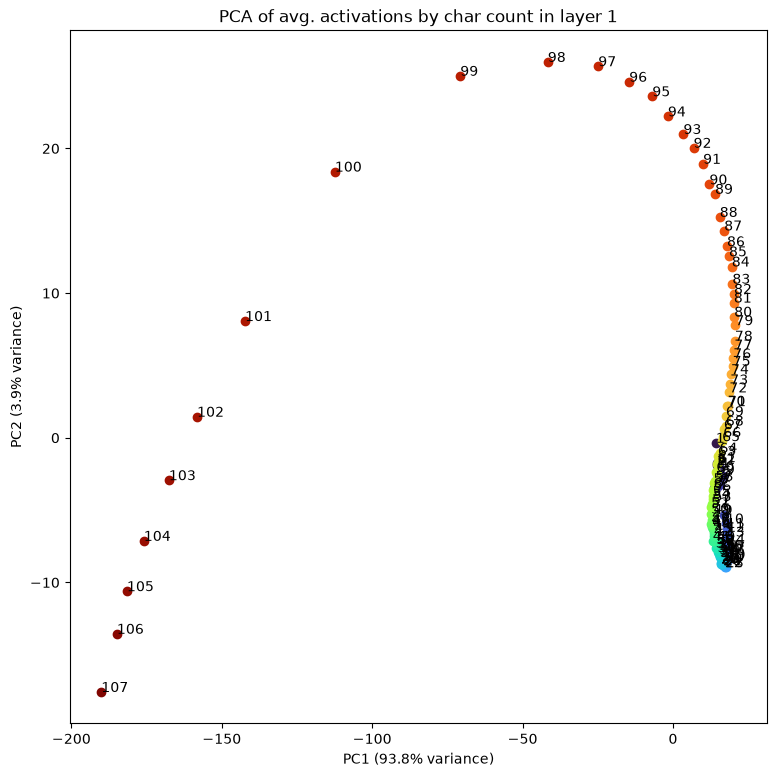

In [15]:
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, Normalize
cmap = plt.get_cmap("turbo", 109)
colors = cmap(np.linspace(0, 1, 109))

pca = PCA(n_components=2)
act_pca = pca.fit_transform(avg_act_matrix)
print(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 9))


for row_idx, character_count in enumerate(relevant_character_counts):
    x, y = act_pca[row_idx]
    plt.scatter(x, y, color=colors[character_count])
    plt.annotate(character_count, (x, y))

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)"
)
plt.title(f"PCA of avg. activations by char count in layer {layer}")
plt.show()


[0.9379314  0.03937757 0.01230537]


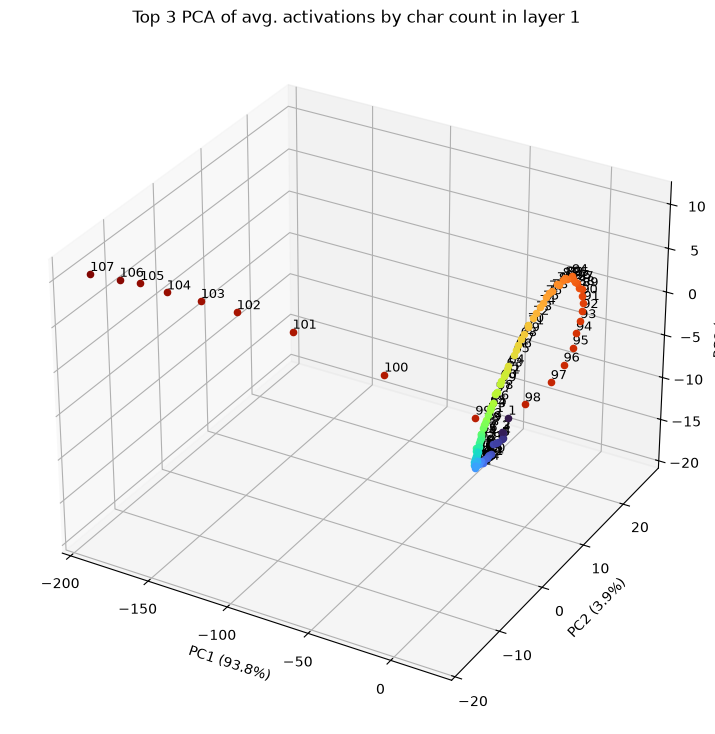

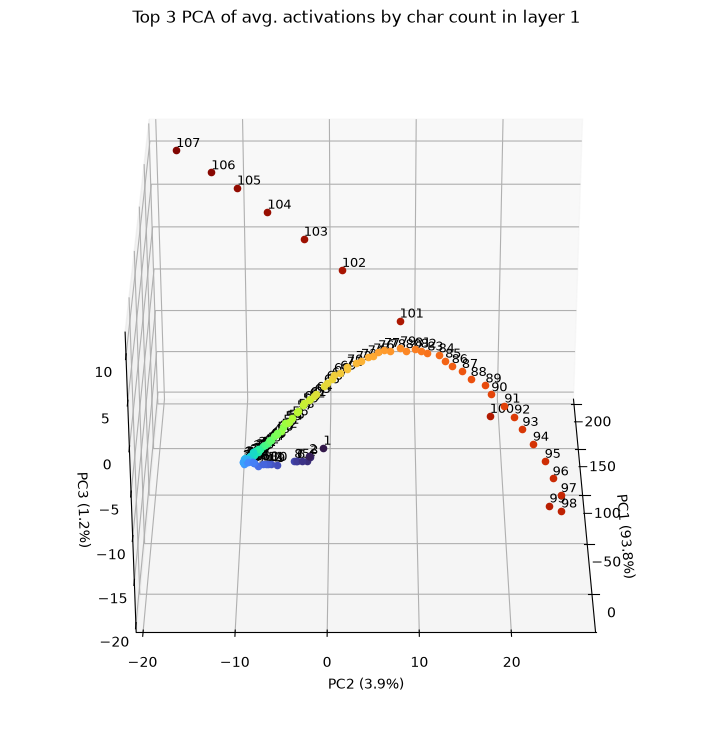

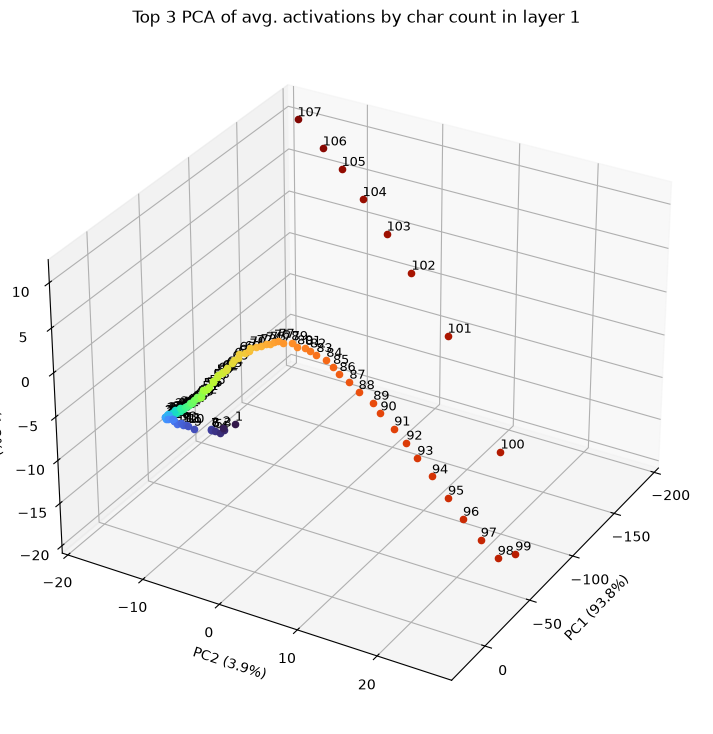

In [16]:
three_dim_pca = PCA(n_components=3)
three_act_pca = three_dim_pca.fit_transform(avg_act_matrix)
print(three_dim_pca.explained_variance_ratio_)


def plot_three_dim_activations(elev,azim):
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(projection='3d')

    for row_idx, character_count in enumerate(relevant_character_counts):
        x, y, z = three_act_pca[row_idx]
        ax.scatter(x, y,z, color=colors[character_count])
        ax.text(
            x,
            y,
            z,
            str(character_count),
            fontsize=9,
            ha="left",
            va="bottom",
        )

    ax.set_xlabel(f"PC1 ({three_dim_pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({three_dim_pca.explained_variance_ratio_[1]:.1%})")
    ax.set_zlabel(f"PC3 ({three_dim_pca.explained_variance_ratio_[2]:.1%})")
    ax.view_init(elev=elev, azim=azim)

    plt.title(f"Top 3 PCA of avg. activations by char count in layer {layer}")
    plt.show()
    fig.subplots_adjust(right=0.85)

plot_three_dim_activations(elev=30, azim=-60)
plot_three_dim_activations(elev=30, azim=0)
plot_three_dim_activations(elev=30, azim=30)



[0.9379314  0.03937757 0.01230537 0.00551751 0.00251683 0.00128173]


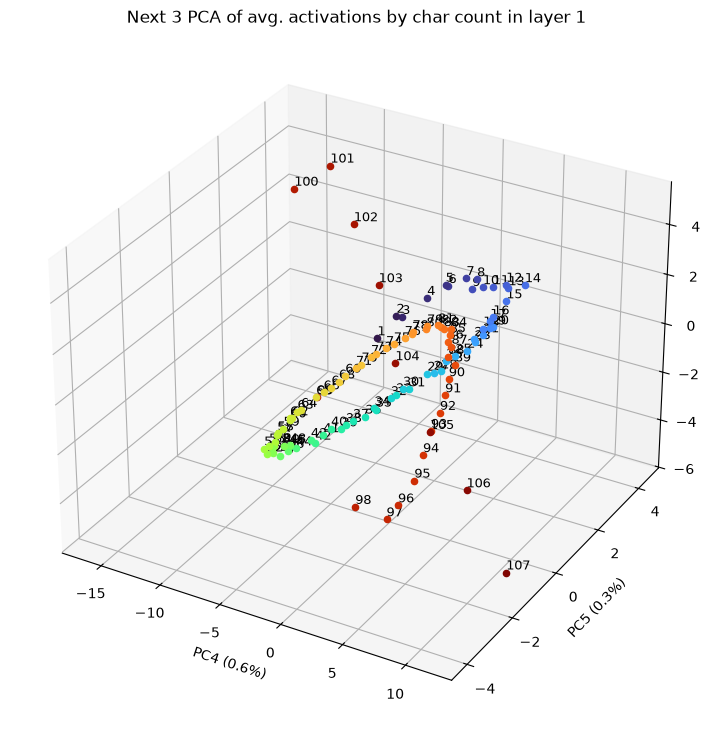

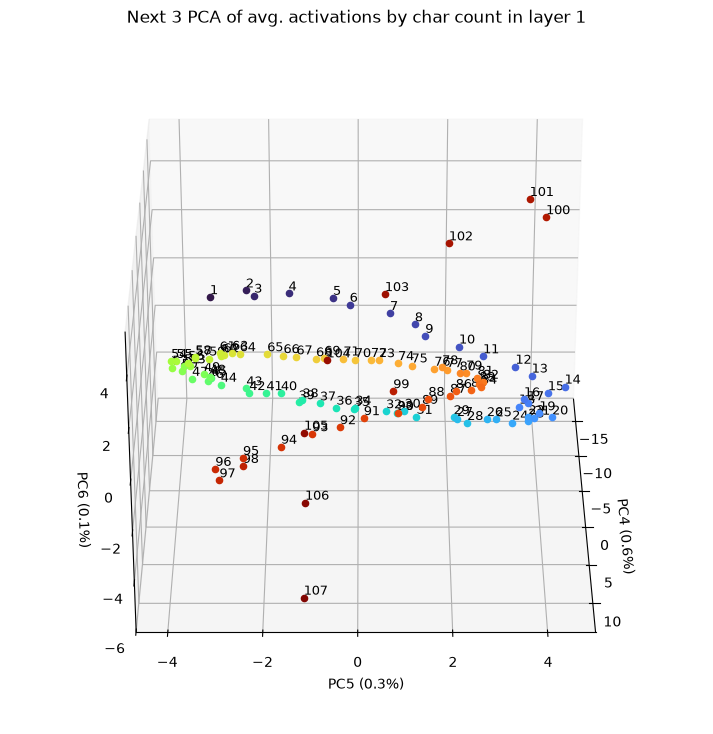

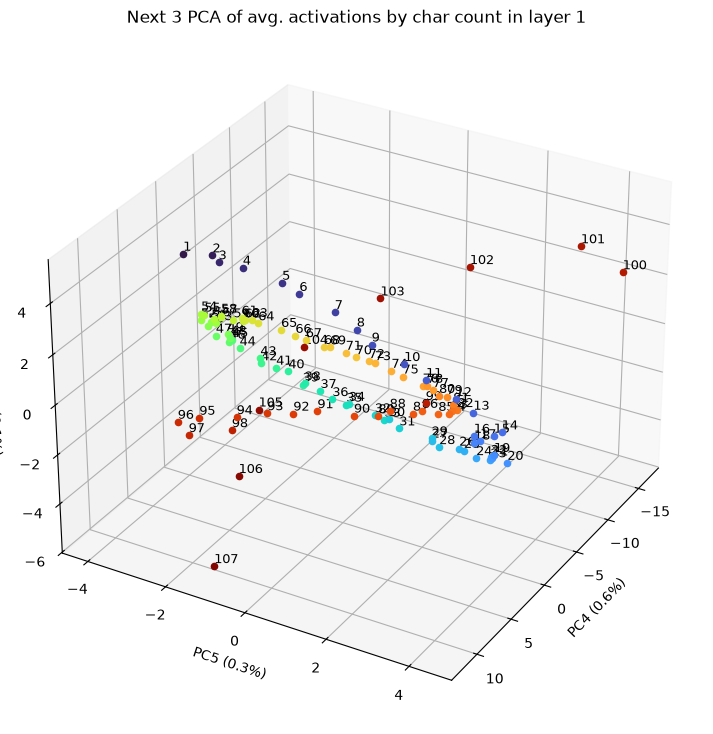

In [17]:
six_dim_pca = PCA(n_components=6)
six_act_pca = six_dim_pca.fit_transform(avg_act_matrix)
print(six_dim_pca.explained_variance_ratio_)


def plot_next_three_dim_activations(elev,azim):
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(projection='3d')

    for row_idx, character_count in enumerate(relevant_character_counts):
        a,b,c,x, y, z = six_act_pca[row_idx]
        ax.scatter(x, y,z, color=colors[character_count])
        ax.text(
            x,
            y,
            z,
            str(character_count),
            fontsize=9,
            ha="left",
            va="bottom",
        )

    ax.set_xlabel(f"PC4 ({six_dim_pca.explained_variance_ratio_[3]:.1%})")
    ax.set_ylabel(f"PC5 ({six_dim_pca.explained_variance_ratio_[4]:.1%})")
    ax.set_zlabel(f"PC6 ({six_dim_pca.explained_variance_ratio_[5]:.1%})")
    ax.view_init(elev=elev, azim=azim)

    plt.title(f"Next 3 PCA of avg. activations by char count in layer {layer}")
    plt.show()
    fig.subplots_adjust(right=0.85)

plot_next_three_dim_activations(elev=30, azim=-60)
plot_next_three_dim_activations(elev=30, azim=0)
plot_next_three_dim_activations(elev=30, azim=30)

